# Exercise: Exploring Attention Heads in GPT-2

In this exercise you will choose **4 sentences of your own** and examine what one of GPT-2's attention heads has "learned" to pay attention to.

GPT-2 has:
- **12 transformer layers** (layer indices `0` – `11`)
- **12 attention heads per layer** (head indices `0` – `11`)

Each head has its own Query, Key, and Value projection matrices and therefore learns to look for a different kind of relationship between tokens.

### Your tasks
1. Run the setup cells below to load GPT-2.
2. In the **"Your Turn"** cell, replace the placeholder sentences with **4 sentences of your own** and choose a layer and head to investigate.
3. Run the visualisation cells and study the resulting attention matrix.
4. Try to describe *what kind of token relationships* that head appears to focus on.

## Step 1 – Load GPT-2 and set up utilities

Run the cell below to load GPT-2, its tokenizer, and all helper functions you will need.

In [1]:
import torch
import torch.nn.functional as F
import tiktoken
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from transformers import GPT2LMHeadModel

# ── Load GPT-2 (124 M) ──────────────────────────────────────────────────────
model_hf = GPT2LMHeadModel.from_pretrained("gpt2")
sd_hf    = model_hf.state_dict()
enc      = tiktoken.get_encoding("gpt2")

# Model constants
D_MODEL  = 768   # hidden dimension
N_LAYERS = 12    # transformer layers  (valid layer indices: 0–11)
N_HEADS  = 12    # attention heads     (valid head  indices: 0–11)
HEAD_DIM = D_MODEL // N_HEADS   # 64

# ── Token and position embedding tables ─────────────────────────────────────
wte = sd_hf["transformer.wte.weight"]   # [50257, 768]
wpe = sd_hf["transformer.wpe.weight"]   # [1024,  768]

print(f"GPT-2 loaded successfully.")
print(f"  Layers : {N_LAYERS}  (choose layer_num in 0–{N_LAYERS-1})")
print(f"  Heads  : {N_HEADS}   (choose head_idx  in 0–{N_HEADS -1})")

GPT-2 loaded successfully.
  Layers : 12  (choose layer_num in 0–11)
  Heads  : 12   (choose head_idx  in 0–11)


In [2]:
def get_attention_matrix(sentence, layer_num, head_idx):
    """
    Compute the (causal) attention weight matrix for a single sentence,
    a specific transformer layer, and a specific attention head.

    Parameters
    ----------
    sentence  : str   – the input text
    layer_num : int   – transformer layer index (0–11)
    head_idx  : int   – attention head index    (0–11)

    Returns
    -------
    tokens          : list[str]          – token strings (for axis labels)
    attention_array : np.ndarray [T, T]  – attention weights (upper triangle masked)
    """
    # Tokenise
    token_ids  = enc.encode(sentence)
    tokens     = [enc.decode([tid]) for tid in token_ids]
    T          = len(tokens)

    # Build input embeddings  (token + position)
    pos_ids          = torch.arange(T)
    input_embeddings = wte[token_ids] + wpe[pos_ids]   # [T, 768]

    # Extract Q and K weights for the chosen layer and head
    qkv_weight = sd_hf[f"transformer.h.{layer_num}.attn.c_attn.weight"]   # [768, 2304]
    qkv_bias   = sd_hf[f"transformer.h.{layer_num}.attn.c_attn.bias"]     # [2304]
    q_weight, k_weight, _ = qkv_weight.split(D_MODEL, dim=1)
    q_bias,   k_bias,   _ = qkv_bias.split(D_MODEL)

    start = head_idx * HEAD_DIM
    end   = start + HEAD_DIM

    Q = input_embeddings @ q_weight[:, start:end] + q_bias[start:end]   # [T, 64]
    K = input_embeddings @ k_weight[:, start:end] + k_bias[start:end]   # [T, 64]

    # Scaled dot-product attention with causal mask
    scores       = Q @ K.T / (HEAD_DIM ** 0.5)                          # [T, T]
    causal_mask  = torch.tril(torch.ones(T, T))
    causal_mask  = torch.where(causal_mask == 0, float('-inf'), 0.0)
    scores       = scores + causal_mask
    weights      = F.softmax(scores, dim=-1)                             # [T, T]

    # Mask upper triangle so the plot isn't misleading
    arr  = weights.detach().numpy()
    mask = np.triu(np.ones_like(arr, dtype=bool), k=1)
    return tokens, np.ma.array(arr, mask=mask)


def plot_attention(tokens, attention_array, layer_num, head_idx, ax=None, title=None):
    """Plot a single attention matrix with token labels."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 6))

    cmap = plt.cm.Blues.copy()
    cmap.set_bad("white")          # masked (future) tokens shown as white

    im = ax.imshow(attention_array, cmap=cmap, vmin=0, aspect="auto")
    ax.set_xticks(range(len(tokens)));  ax.set_xticklabels(tokens, rotation=90, fontsize=9)
    ax.set_yticks(range(len(tokens)));  ax.set_yticklabels(tokens, fontsize=9)
    ax.set_xlabel("Key  (token being attended to)",    fontsize=9)
    ax.set_ylabel("Query (token doing the attending)", fontsize=9)
    ax.set_title(title or f"Layer {layer_num}  ·  Head {head_idx}", fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    if standalone:
        plt.tight_layout()
        plt.show()

print("Helper functions defined.")

Helper functions defined.


## Step 2 – Your Turn ✏️

In the cell below, replace the placeholder sentences with **4 sentences of your own**.  
They can be on any topic, but consider mixing:
- sentences with clear grammatical structure (subjects, verbs, objects)
- sentences that share some vocabulary
- sentences with pronouns or possessives

Then choose a **layer** (0–11) and a **head** (0–11) you want to investigate.  
Don't worry about picking the "right" answer – the goal is to explore!

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  TODO – fill in YOUR sentences below, then choose a layer and head
# ═══════════════════════════════════════════════════════════════════════════

sentences = [
    "Replace this with your first sentence here",
    "Replace this with your second sentence here",
    "Replace this with your third sentence here",
    "Replace this with your fourth sentence here",
]

# Which transformer layer do you want to examine?  (integer 0–11)
layer_num = 0

# Which attention head within that layer?  (integer 0–11)
head_idx = 0

# ═══════════════════════════════════════════════════════════════════════════
print(f"You will inspect  Layer {layer_num}  →  Head {head_idx}")
print(f"Your sentences:")
for i, s in enumerate(sentences, 1):
    print(f"  {i}. {s}")

You will inspect  Layer 4  →  Head 5
Your sentences:
  1. Replace this with your first sentence here
  2. Replace this with your second sentence here
  3. Replace this with your third sentence here
  4. Replace this with your fourth sentence here


## Step 3 – Visualise the Attention Matrix

Run the cell below to produce an attention-weight heatmap for each of your sentences.

Each cell $(i, j)$ of the matrix shows **how much token $i$ attends to token $j$** (darker = stronger attention).  
Because GPT-2 is causal (auto-regressive), a token can only attend to *itself and earlier tokens*, so the upper triangle is always empty.

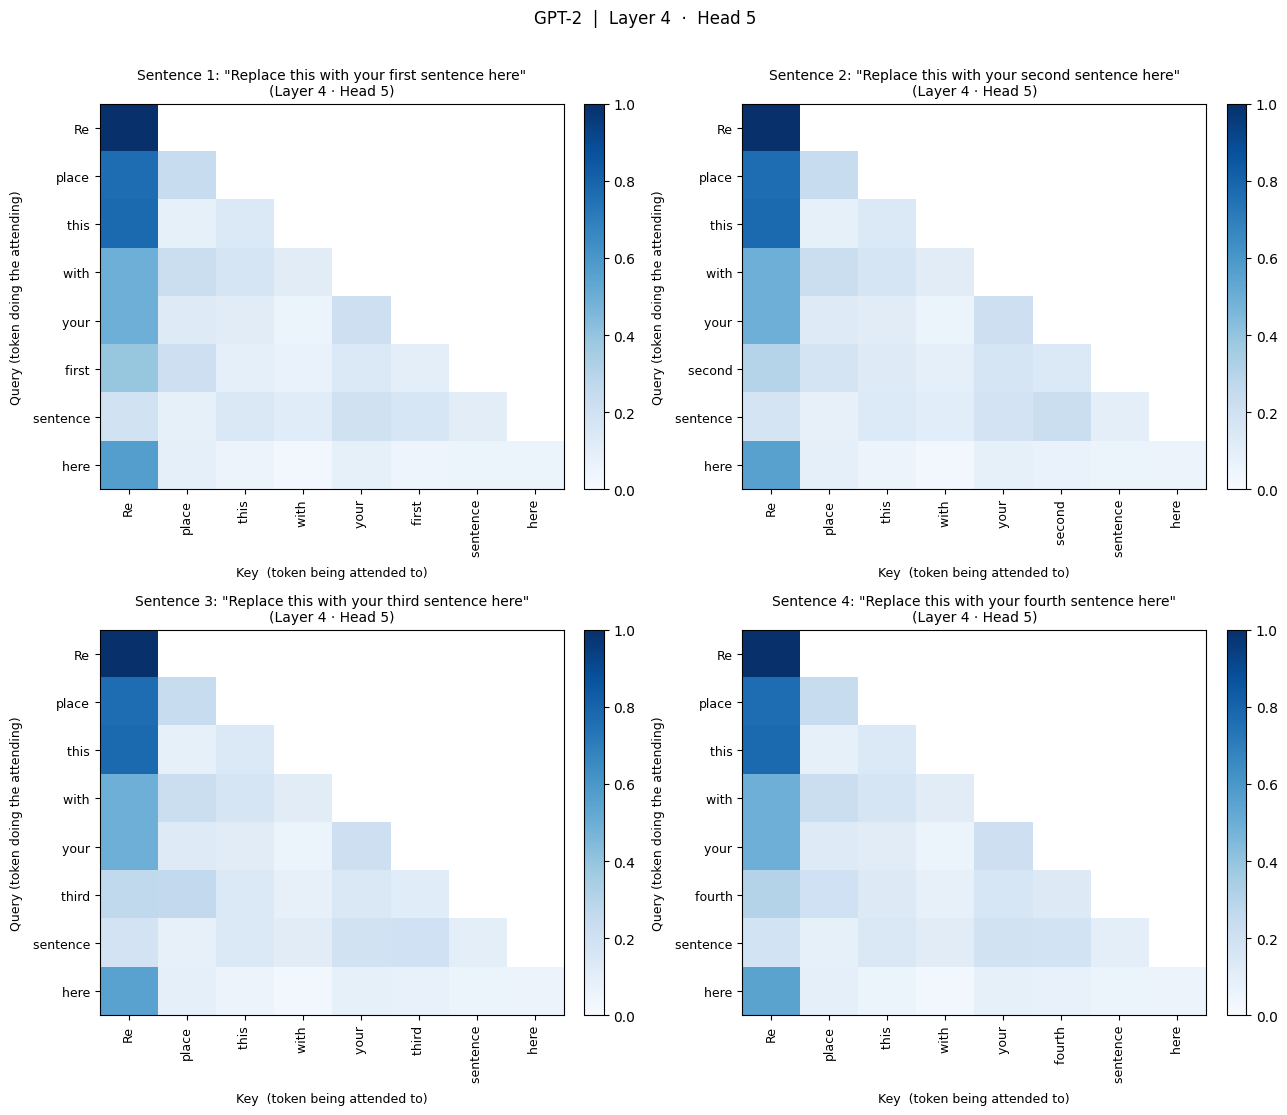

In [9]:
n = len(sentences)
cols = 2
rows = (n + 1) // 2

fig, axes = plt.subplots(rows, cols, figsize=(cols * 6.5, rows * 5.5))
axes = axes.flatten() if n > 1 else [axes]

for idx, sentence in enumerate(sentences):
    tokens, attn = get_attention_matrix(sentence, layer_num, head_idx)
    short_title = sentence if len(sentence) <= 45 else sentence[:42] + "…"
    plot_attention(tokens, attn, layer_num, head_idx,
                   ax=axes[idx],
                   title=f'Sentence {idx+1}: "{short_title}"\n(Layer {layer_num} · Head {head_idx})')

# Hide any unused subplot slots
for idx in range(n, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f"GPT-2  |  Layer {layer_num}  ·  Head {head_idx}", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Step 4 – Reflect and Explore Further

### Discussion questions

1. **What pattern do you see?**  
   For each sentence, describe in one sentence what the head seems to be attending to.  
   For example: *"It mainly attends to the previous token"*, *"Verbs strongly attend to their subject"*, *"Punctuation draws a lot of attention"*, etc.

2. **Is the pattern consistent across your 4 sentences?**  
   Or does the head behave differently depending on sentence content?

3. **Try a different head.**  
   Go back to the TODO cell, change `head_idx` to a new value, re-run both cells, and compare.  
   What changed?

4. **Try a later layer.**  
   Change `layer_num` to `6` or `11`.  
   Do heads in later layers capture different relationships than heads in layer 0?

### Bonus: compare two heads side by side

Run the cell below to plot two heads on the same sentence for easy comparison.

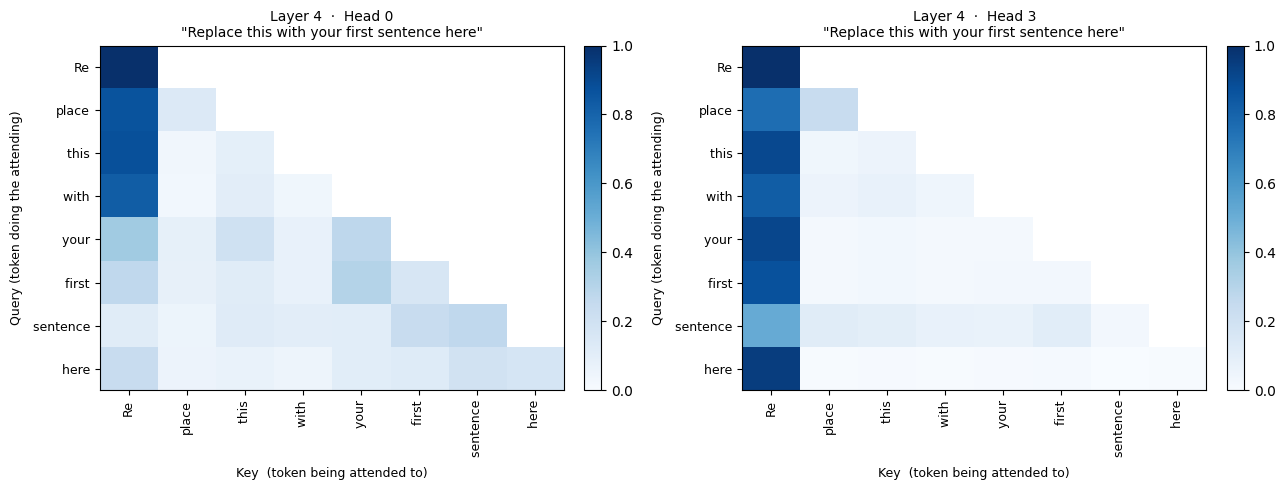

In [10]:
# ── Bonus: compare two heads on the same sentence ───────────────────────────
# Change these to whatever you like
compare_sentence = sentences[0]   # which sentence to use
compare_layer    = layer_num      # layer to inspect
head_A = 0                        # first  head to compare
head_B = 3                        # second head to compare

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, hd in zip([ax1, ax2], [head_A, head_B]):
    tokens, attn = get_attention_matrix(compare_sentence, compare_layer, hd)
    short = compare_sentence if len(compare_sentence) <= 45 else compare_sentence[:42] + "…"
    plot_attention(tokens, attn, compare_layer, hd,
                   ax=ax,
                   title=f'Layer {compare_layer}  ·  Head {hd}\n"{short}"')

plt.tight_layout()
plt.show()